# Evaluation

- Evaluate training and test data distributions
- Display feature importances
- Inspect SHAP results

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr

import dask.dataframe as dd
import dask.array as da

from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
import shap

import yaml
import sys
sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import data_transform
from xgb_preprocess import prepare_data
from gso_preprocess import datetime_to_lead_time
import clear_sky

In [2]:
model = xgb.XGBRegressor()

# Load Model and Data

In [3]:
config_name = 'vanilla'
# Get configurations from yaml file
with open(f"/home/548/cd3022/repos/solar-nowcast/configs/mouse/{config_name}.yaml") as f:
    config = yaml.safe_load(f)
# Model
model_name = config["model"]["name"]
forecast_lead = config["model"]["forecast_lead"]
# Parameters
random_state = config["model"]["parameters"]["random_state"]
n_estimators = config["model"]["parameters"]["n_estimators"]
early_stopping_rounds = config["model"]["parameters"]["early_stopping_rounds"]
learning_rate = config["model"]["parameters"]["learning_rate"]
eval_metric = config["model"]["parameters"]["eval_metric"]

# Data
X_vars = config["data"]["predictors"]
target = config["data"]["target"]
y_var = f'{target}_t{forecast_lead}'
all_vars = X_vars + [y_var]

In [4]:
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

In [5]:
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_files = []

for f in data_path.glob("all_training_month*"):
    month = f.name.split("_")[-1][:2]  # adjust to your naming

    if month in ['02', '06', '10']:
        test_files.append(str(f))

df  = dd.read_parquet(test_files, columns=all_vars)
df = df.compute()

In [6]:
X = df[X_vars]
y = df[y_var]

preds = model.predict(X)

df[f'xgb_t{forecast_lead}'] = preds
ds_xgb = df.to_xarray()
ds_xgb = ds_xgb.compute()

# Load GSO Optical Flow

In [7]:
# Load GSO Optical Flow forecast
ds_gso = xr.open_dataset("/scratch/er8/cd3022/xgb_datasets/gso_csi_testing.nc")

# Performancs Analysis
How does the model perform under different conditions?

In [8]:
explainer = shap.Explainer(model)

In [9]:
def rmse(obs, fcst):
    mse = np.mean((fcst - obs) ** 2)
    rmse = np.sqrt(mse)
    return rmse

In [10]:
def shap_analysis(ds, df, X_vars, explainer):

    times = pd.to_datetime(ds.time.values)
    
    shap_df = df[df.index.get_level_values('time').isin(times)]

    # select the predictor variables
    X = shap_df[X_vars]

    # get smaller sample size to reduce shap load time
    n = min(len(X), 20000)
    idx = np.random.choice(len(X), size=n, replace=False)
    X_sample = X.iloc[idx]

    # Use sample to get SHAP explainer values
    shap_values = explainer(X_sample)

    # Plot results
    # shap.plots.bar(shap_values)
    shap.plots.beeswarm(shap_values)
    return

In [11]:
# RMSE for all times

obs = ds_xgb[f'csi_t{forecast_lead}']
fcst_xgb = ds_xgb[f'xgb_t{forecast_lead}']
fcst_gso = ds_gso['csi_gso']

rmse_xgb = rmse(obs, fcst_xgb)
print(f"XGBoost RMSE: {rmse_xgb.item()}")

rmse_gso = rmse(obs, fcst_gso)
print(f"Optical Flow RMSE: {rmse_gso.item()}")

XGBoost RMSE: 0.18721851247411647
Optical Flow RMSE: 0.2253351688087019


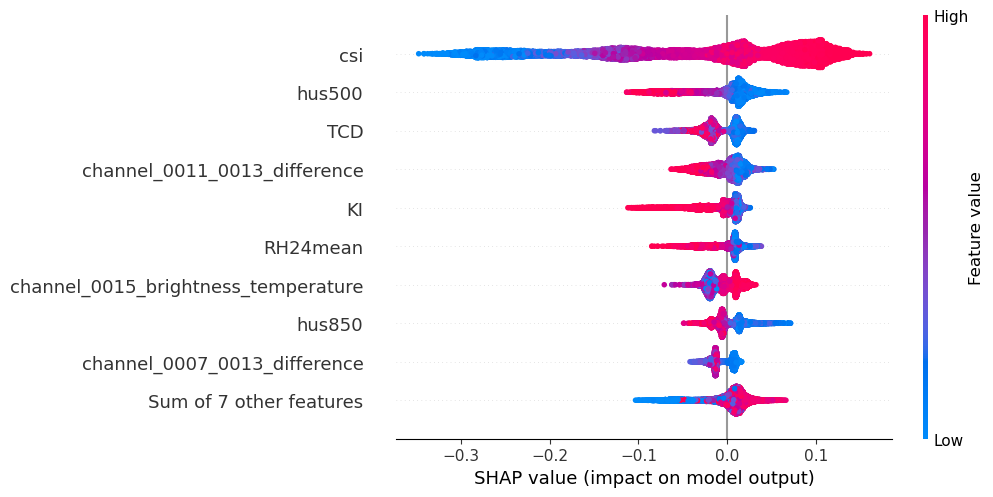

In [12]:
shap_analysis(
    ds=ds_xgb,
    df=df,
    X_vars=X_vars,
    explainer=explainer
)

Month: 02
XGBoost RMSE: 0.20668544569095862
Optical Flow RMSE: 0.24825142872885508


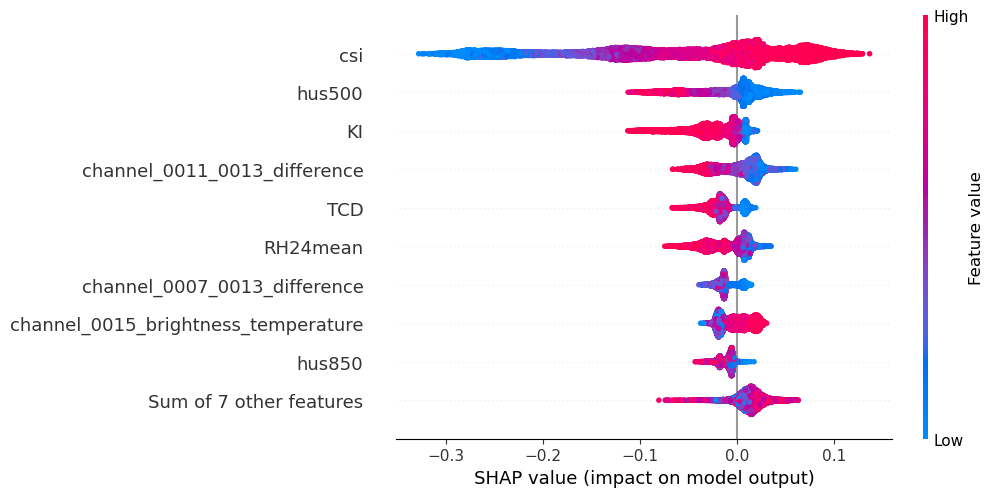

Month: 06
XGBoost RMSE: 0.20229094801482533
Optical Flow RMSE: 0.2541085824668476


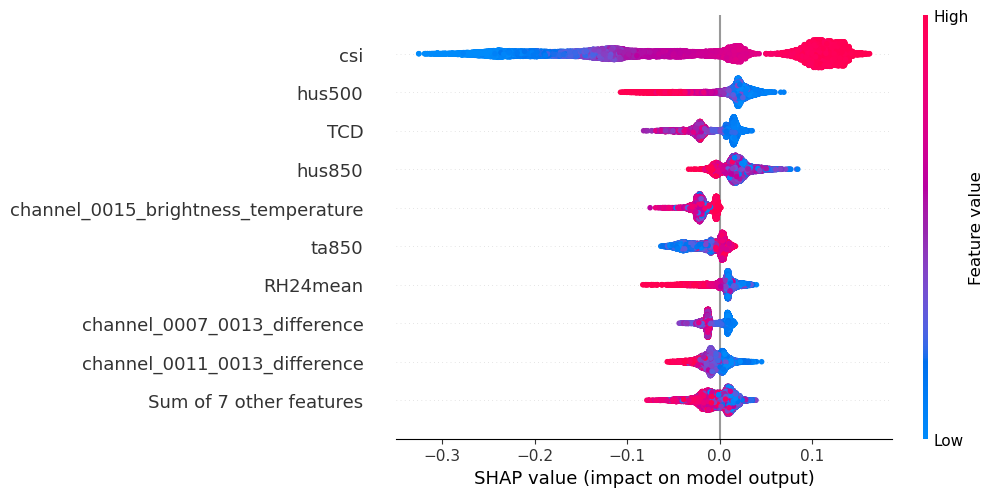

Month: 10
XGBoost RMSE: 0.14713879773432356
Optical Flow RMSE: 0.1683819182278921


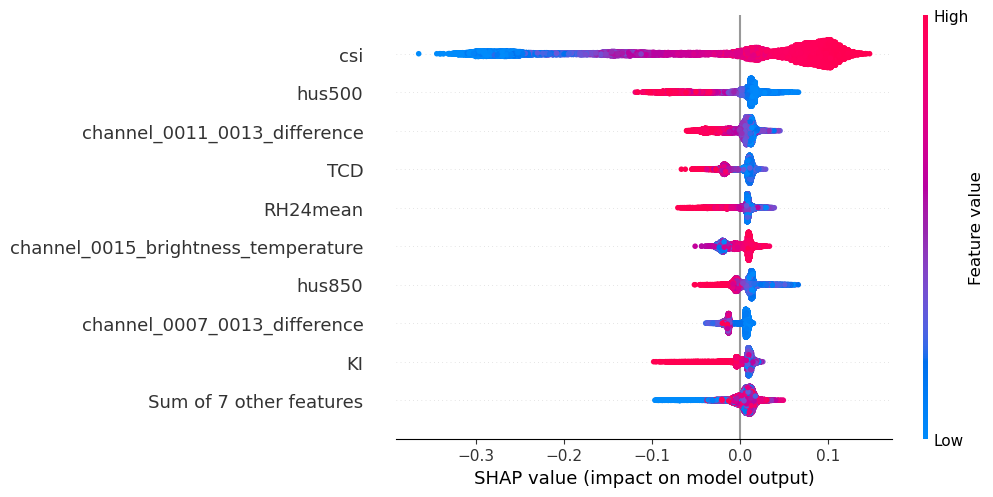

In [14]:
# RMSE by month

for month, month_ds in ds_xgb.groupby('time.month'):
    
    obs = month_ds[f'csi_t{forecast_lead}']
    fcst_xgb = month_ds[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=month_ds.time)
    
    rmse_xgb = rmse(obs, fcst_xgb)
    print(f"Month: {month:02d}")
    print(f"XGBoost RMSE: {rmse_xgb.item()}")
    
    rmse_gso = rmse(obs, fcst_gso)
    print(f"Optical Flow RMSE: {rmse_gso.item()}")
    shap_analysis(
        ds=month_ds,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )

In [69]:
daily_mean_csi = ds_xgb[f'csi_t{forecast_lead}'].resample(time='1D').mean()
daily_regional_mean = daily_mean_csi.mean(['latitude', 'longitude'])

CSI Range: 0 - 0.6
XGBoost RMSE: 0.22806834050375022
Optical Flow RMSE: 0.25832322388687234


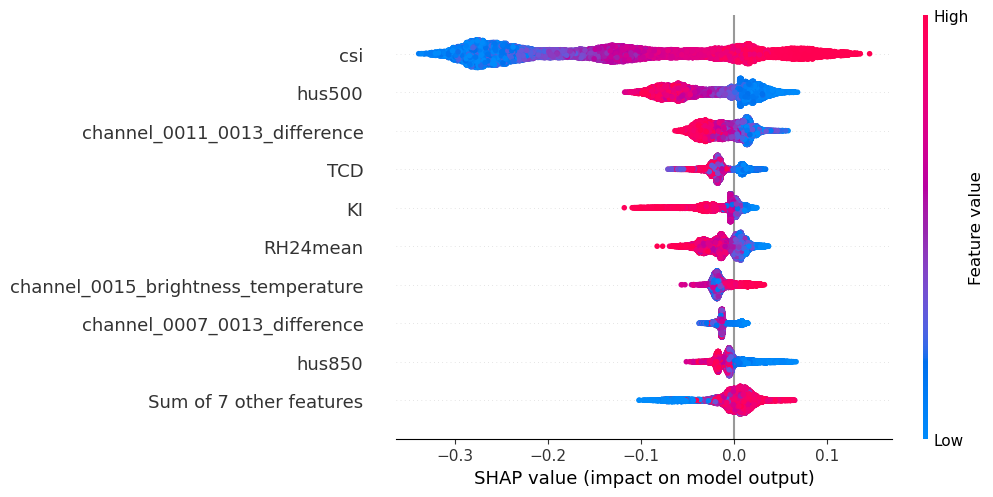

CSI Range: 0.6 - 0.8
XGBoost RMSE: 0.21791304239095108
Optical Flow RMSE: 0.2572959039336877


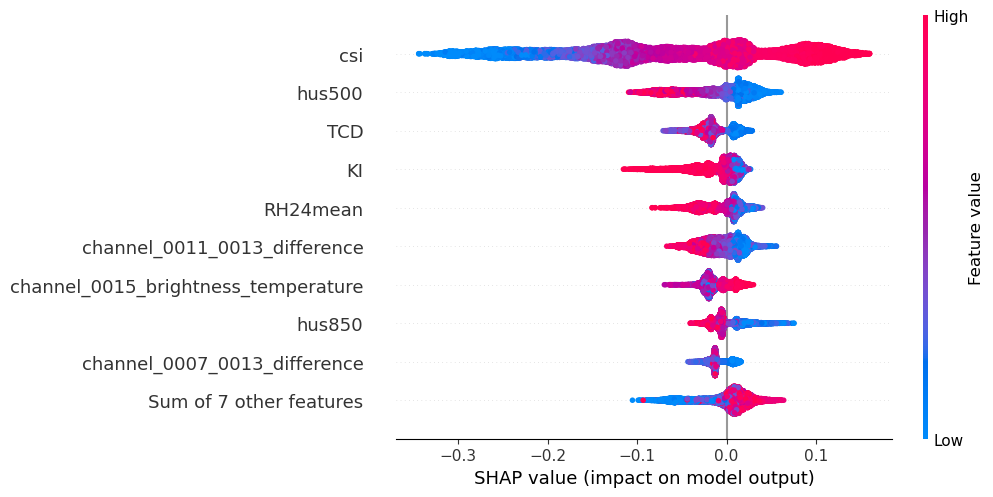

CSI Range: 0.8 - 10
XGBoost RMSE: 0.13255242107826087
Optical Flow RMSE: 0.17750442310297318


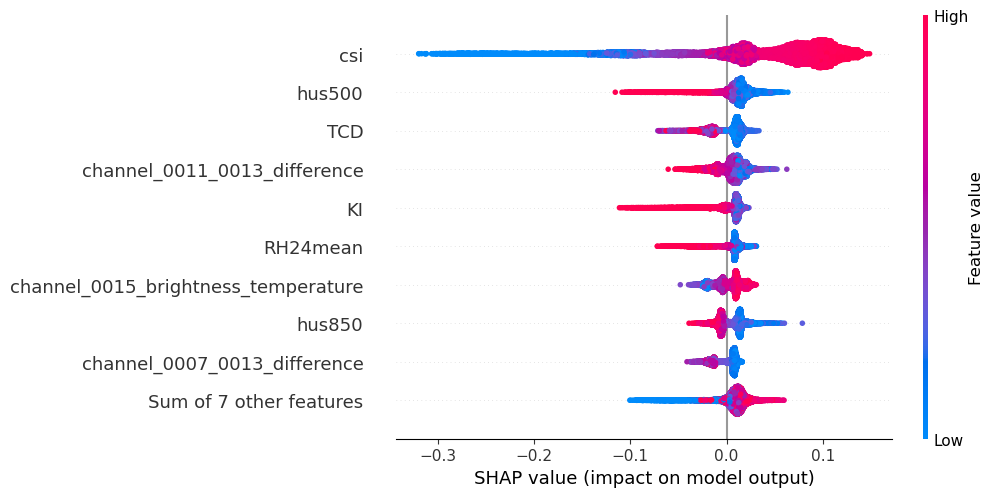

In [96]:
# By CSI magnitude

csi_ranges = [
    (0, 0.6),
    (0.6, 0.8),
    (0.8, 10),
]

# Daily mean CSI
daily_mean_csi = ds_xgb[f'csi_t{forecast_lead}'].resample(time='1D').mean()

for csi_min, csi_max in csi_ranges:

    # Select days whose DAILY MEAN CSI falls in range
    valid_days = daily_regional_mean.time.where(
        (daily_regional_mean > csi_min) &
        (daily_regional_mean < csi_max),
        drop=True
    )
    # Get dates only
    valid_dates = valid_days.dt.floor('D')

    # Match all timestamps belonging to those days
    mask = ds_xgb.time.dt.floor('D').isin(valid_dates)
    ds_range = ds_xgb.where(mask, drop=True)

    obs = ds_range[f'csi_t{forecast_lead}']
    fcst_xgb = ds_range[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=ds_range.time)


    rmse_xgb = rmse(obs, fcst_xgb)
    print(f"CSI Range: {csi_min} - {csi_max}")
    print(f"XGBoost RMSE: {rmse_xgb.item()}")
    
    rmse_gso = rmse(obs, fcst_gso)
    print(f"Optical Flow RMSE: {rmse_gso.item()}")
    shap_analysis(
        ds=ds_range,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )

CSI Range: -10 - -0.1
XGBoost RMSE: 0.2230656632795883
Optical Flow RMSE: 0.2682581981826755


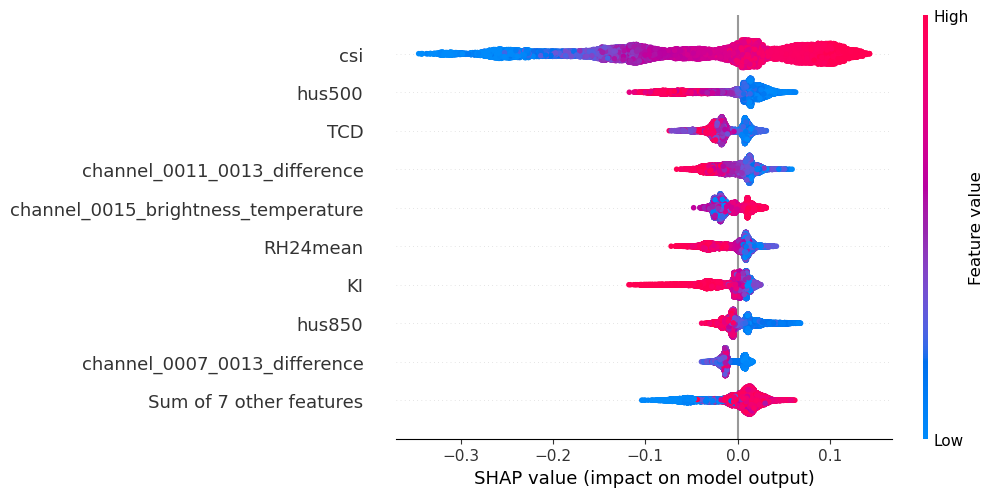

CSI Range: -0.1 - 0.0
XGBoost RMSE: 0.17840026173202153
Optical Flow RMSE: 0.2154364387225871


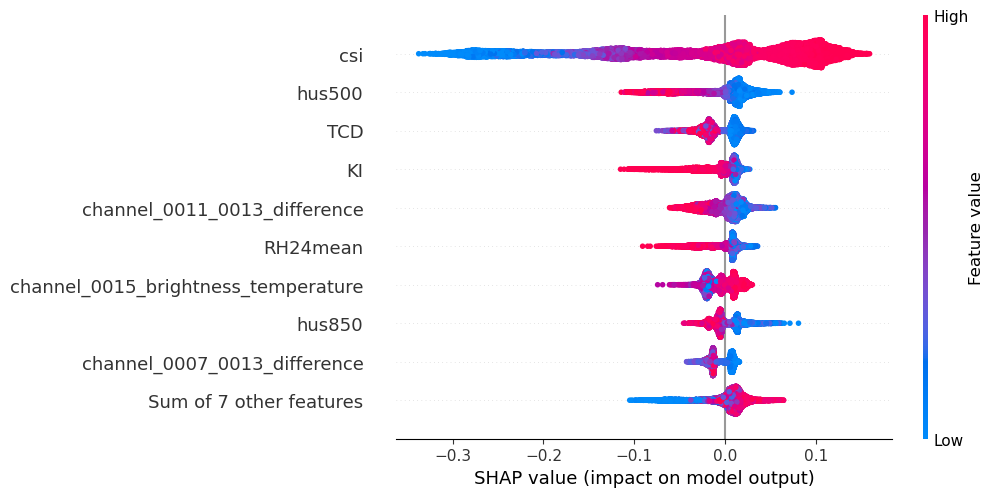

CSI Range: 0.0 - 10
XGBoost RMSE: 0.20627081966203675
Optical Flow RMSE: 0.24081844647759784


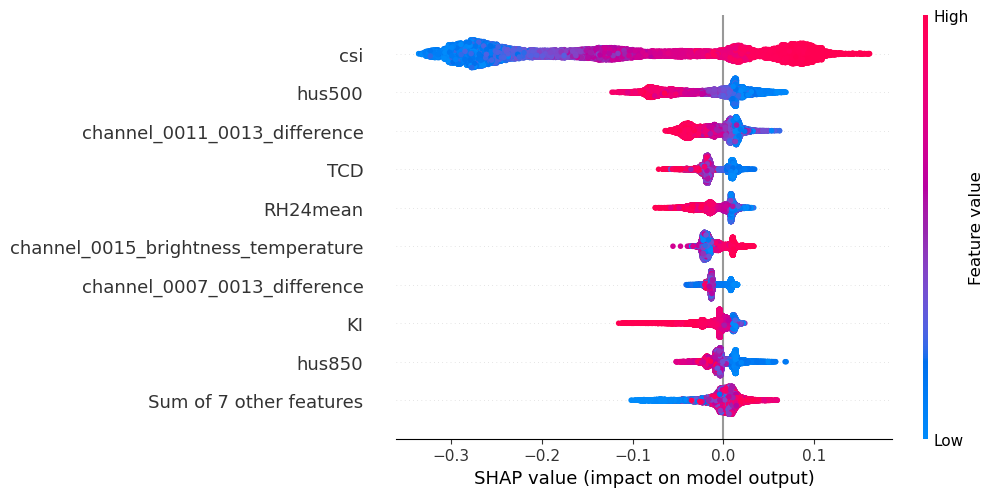

In [97]:
# By change in CSI

reg_mean = ds_xgb.mean(['latitude', 'longitude'])
reg_mean_delta = reg_mean[f'csi_t{forecast_lead}'] - reg_mean['csi']

delta_range = [
    (-10, -0.1),
    (-0.1, 0.0),
    (0.0, 10)
]

for delta_min, delta_max in delta_range:
    
    valid_times = reg_mean_delta.time.where(
        (reg_mean_delta > delta_min) &
        (reg_mean_delta < delta_max),
        drop=True
    )

    # Match all timestamps belonging to those days
    mask = ds_xgb.time.isin(valid_times)
    ds_range = ds_xgb.where(mask, drop=True)

    obs = ds_range[f'csi_t{forecast_lead}']
    fcst_xgb = ds_range[f'xgb_t{forecast_lead}']
    fcst_gso = ds_gso['csi_gso'].sel(time=ds_range.time)


    rmse_xgb = rmse(obs, fcst_xgb)
    print(f"CSI Range: {delta_min} - {delta_max}")
    print(f"XGBoost RMSE: {rmse_xgb.item()}")
    
    rmse_gso = rmse(obs, fcst_gso)
    print(f"Optical Flow RMSE: {rmse_gso.item()}")
    shap_analysis(
        ds=ds_range,
        df=df,
        X_vars=X_vars,
        explainer=explainer
    )